# Did the prompt change break something, or is that the noise?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/prompt-regression-ci/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/prompt-regression-ci/demo.ipynb)

A pull request edits a prompt. CI runs a 300-case held-out set under the old and new prompt and posts
a behavioural diff: the cases that passed before and fail now. An LLM does not give the same answer
twice, so that list is never empty - even when nothing changed. This notebook computes, exactly, how
often each gating rule goes red for nothing, what threshold makes it honest, and which real breaks
each rule can and cannot see.

1. Calibration - exact probabilities vs raw simulated runs
2. A no-op PR under six rules
3. Three kinds of real break
4. Negative result - quarantine goes blind where the set is flaky
5. Try your own

## The engine

Extracted from `gate.py` at build time, character for character. Each case has a per-run pass
probability under each prompt and runs are independent, so the chance that a rule lists a case as broken
is a sum of binomial pmf products, and the number of listed cases is a Poisson-binomial computed by exact
convolution. Nothing below is sampled except the calibration check.

In [1]:
from __future__ import annotations

from functools import lru_cache
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA_GATE = 0.05  # target false-red rate for a no-op PR


N_STABLE_PASS, N_STABLE_FAIL, N_FLAKY = 246, 24, 30


N = N_STABLE_PASS + N_STABLE_FAIL + N_FLAKY


STABLE_P = 0.995  # a "stable" pass still fails 1 run in 200


Q_RUNS = 4  # baseline re-runs used to find flaky cases


N_BREAK = 6  # cases a real side effect breaks


PRS_PER_MONTH = 40


SEED = 2026


RULES: Tuple[Tuple[str, str, int, bool], ...] = (
    ("naive k=1", "majority", 1, False),
    ("majority k=3", "majority", 3, False),
    ("majority k=5", "majority", 5, False),
    ("fisher k=5", "fisher", 5, False),
    ("quarantine + naive k=1", "majority", 1, True),
    ("quarantine + majority k=3", "majority", 3, True),
)


SCENARIOS = ("no-op", "hard break", "intermittent break", "break on flaky cases")


MC_REPS = 20000


def held_out_set(seed: int = SEED) -> np.ndarray:
    """Per-run pass probability of each case under prompt A. Flaky cases draw pi from Beta(2, 2)."""
    rng = np.random.default_rng(seed)
    return np.r_[np.full(N_STABLE_PASS, STABLE_P), np.full(N_STABLE_FAIL, 1 - STABLE_P), rng.beta(2, 2, N_FLAKY)]


def scenario(name: str, pi_a: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """(pi_b, is_really_broken). Breaks hit the first N_BREAK cases of the relevant block."""
    pi_b, real = pi_a.copy(), np.zeros(len(pi_a), dtype=bool)
    if name == "no-op":
        return pi_b, real
    idx = np.arange(N_BREAK) if name != "break on flaky cases" else N_STABLE_PASS + N_STABLE_FAIL + np.arange(N_BREAK)
    pi_b[idx] = {"hard break": 1 - STABLE_P, "intermittent break": 0.5, "break on flaky cases": 1 - STABLE_P}[name]
    real[idx] = True
    return pi_b, real


@lru_cache(maxsize=None)
def reject_table(kind: str, k: int) -> np.ndarray:
    """reject[a, b] = does the rule flag a case with a passes of k under A and b passes of k under B."""
    a, b = np.meshgrid(np.arange(k + 1), np.arange(k + 1), indexing="ij")
    if kind == "majority":
        return (a > k / 2) & (b < k / 2)
    if kind == "fisher":
        out = np.zeros((k + 1, k + 1), dtype=bool)
        for i in range(k + 1):
            for j in range(k + 1):
                if i > j:
                    out[i, j] = stats.fisher_exact([[i, k - i], [j, k - j]], alternative="greater")[1] < 0.05
        return out
    raise ValueError(kind)


def flag_prob(pi_a: np.ndarray, pi_b: np.ndarray, kind: str, k: int, quarantine: bool) -> np.ndarray:
    """Exact per-case probability of being listed as broken."""
    ks = np.arange(k + 1)
    pa = stats.binom.pmf(ks[None, :], k, np.asarray(pi_a)[:, None])
    pb = stats.binom.pmf(ks[None, :], k, np.asarray(pi_b)[:, None])
    p = np.einsum("ia,ab,ib->i", pa, reject_table(kind, k).astype(float), pb)
    return p * not_quarantined(pi_a) if quarantine else p


def not_quarantined(pi_a: np.ndarray, runs: int = Q_RUNS) -> np.ndarray:
    """A case survives quarantine if all baseline runs agree (baseline runs are separate from the gate's)."""
    pi_a = np.asarray(pi_a)
    return pi_a ** runs + (1 - pi_a) ** runs


def count_pmf(p: np.ndarray) -> np.ndarray:
    """Poisson-binomial pmf of the number of flagged cases, by exact convolution."""
    pmf = np.array([1.0])
    for pi in p:
        pmf = np.convolve(pmf, [1 - pi, pi])
    return pmf


def red_prob(p: np.ndarray, t: int) -> float:
    return float(count_pmf(p)[t:].sum())


def threshold(p_noop: np.ndarray, alpha: float = ALPHA_GATE) -> int:
    """Smallest T whose no-op false-red rate is <= alpha."""
    tail = np.cumsum(count_pmf(p_noop)[::-1])[::-1]
    return int(np.argmax(tail <= alpha))


def evaluate(pi_a: np.ndarray = None) -> List[Dict]:
    """Every rule under every scenario: false reds, the calibrated threshold, power, report precision, cost."""
    pi_a = held_out_set() if pi_a is None else pi_a
    out = []
    for label, kind, k, quar in RULES:
        p0 = flag_prob(pi_a, pi_a, kind, k, quar)
        t = threshold(p0)
        row = {"rule": label, "k": k, "quarantine": quar, "T": t, "noop_expected_flags": float(p0.sum()),
               "noop_red_at_T1": red_prob(p0, 1), "noop_red_at_T": red_prob(p0, t),
               "month_any_false_red_T1": 1 - (1 - red_prob(p0, 1)) ** PRS_PER_MONTH,
               "month_any_false_red_T": 1 - (1 - red_prob(p0, t)) ** PRS_PER_MONTH,
               "calls_per_pr": 2 * N * k, "gated_cases": float(not_quarantined(pi_a).sum()) if quar else float(N)}
        for sc in SCENARIOS[1:]:
            pi_b, real = scenario(sc, pi_a)
            p = flag_prob(pi_a, pi_b, kind, k, quar)
            row[sc] = {"red_at_T": red_prob(p, t), "red_at_T1": red_prob(p, 1),
                       "recall": float(p[real].mean()), "precision": float(p[real].sum() / p.sum()),
                       "expected_flags": float(p.sum())}
        out.append(row)
    return out


def simulate(pi_a: np.ndarray, pi_b: np.ndarray, kind: str, k: int, quarantine: bool, reps: int,
             seed: int = 7) -> np.ndarray:
    """Raw runs, raw rule: the flagged count in each replicate. The check on the exact engine."""
    rng = np.random.default_rng(seed)
    a = rng.binomial(k, pi_a, size=(reps, len(pi_a)))
    b = rng.binomial(k, pi_b, size=(reps, len(pi_a)))
    flagged = reject_table(kind, k)[a, b]
    if quarantine:
        base = rng.random((reps, len(pi_a), Q_RUNS)) < pi_a[None, :, None]
        flagged &= base.all(axis=2) | (~base).all(axis=2)
    return flagged.sum(axis=1)


def wilson(k: int, n: int, z: float = float(stats.norm.isf(0.005))) -> List[float]:
    p = k / n
    den = 1 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [float(mid - half), float(mid + half)]


def calibrate(reps: int = MC_REPS) -> Dict:
    """Exact red rates vs raw simulation, and the Poisson-binomial vs scipy's binomial where they coincide."""
    pi_a = held_out_set()
    rows = []
    for label, kind, k, quar in RULES:
        t = threshold(flag_prob(pi_a, pi_a, kind, k, quar))
        for sc in ("no-op", "intermittent break"):
            pi_b, _ = scenario(sc, pi_a)
            ex = red_prob(flag_prob(pi_a, pi_b, kind, k, quar), t)
            hits = int((simulate(pi_a, pi_b, kind, k, quar, reps) >= t).sum())
            lo, hi = wilson(hits, reps)
            rows.append({"rule": label, "scenario": sc, "T": t, "exact": ex, "mc": hits / reps,
                         "inside_99": bool(lo <= ex <= hi)})
    same = np.full(50, 0.13)
    gap = float(np.max(np.abs(count_pmf(same) - stats.binom.pmf(np.arange(51), 50, 0.13))))
    return {"red_rates": rows, "poisson_binomial_vs_binom_gap": gap}


def audit(baseline_runs: Sequence[Sequence[int]], candidate_runs: Sequence[Sequence[int]],
          q_runs: Sequence[Sequence[int]] = ()) -> Dict:
    """The app's core: per-case 0/1 results for A and B (k runs each), optional extra baseline runs.

    Returns the naive k=1 diff (first run only), the majority diff, the Fisher diff, which cases a
    quarantine would drop, and the expected number of broken cases a no-op would produce at these
    pass rates - the noise floor to read the diff against.
    """
    a = np.asarray(baseline_runs, dtype=int)
    b = np.asarray(candidate_runs, dtype=int)
    if a.ndim != 2 or a.shape != b.shape or a.size == 0:
        raise ValueError("baseline and candidate must be the same cases x runs grid")
    if not np.isin(a, (0, 1)).all() or not np.isin(b, (0, 1)).all():
        raise ValueError("results must be 0 or 1")
    k = a.shape[1]
    sa, sb = a.sum(axis=1), b.sum(axis=1)
    naive = (a[:, 0] == 1) & (b[:, 0] == 0)
    maj = reject_table("majority", k)[sa, sb] if k % 2 else np.zeros(len(a), dtype=bool)
    fish = reject_table("fisher", k)[sa, sb]
    allbase = np.c_[a, np.asarray(q_runs, dtype=int)] if len(q_runs) else a
    flaky = ~((allbase == 1).all(axis=1) | (allbase == 0).all(axis=1))
    pi_hat = (allbase.sum(axis=1) + 0.5) / (allbase.shape[1] + 1)  # Jeffreys-style, never exactly 0 or 1
    floor = float(flag_prob(pi_hat, pi_hat, "majority", 1, False).sum())
    return {"k": k, "n": len(a), "naive": np.flatnonzero(naive).tolist(), "majority": np.flatnonzero(maj).tolist(),
            "fisher": np.flatnonzero(fish).tolist(), "flaky": np.flatnonzero(flaky).tolist(),
            "noop_floor_naive": floor, "pass_a": float(a.mean()), "pass_b": float(b.mean())}

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every gate number here is exact and matches `evidence.txt` to the digit.
Only the calibration's raw simulation runs at 4,000 replicates instead of the study's 20,000.

## 1. Calibration

In [2]:
cal = calibrate(4000)
print(f"Poisson-binomial vs scipy binom: max gap {cal['poisson_binomial_vs_binom_gap']:.1e}")
for r in cal["red_rates"]:
    print(f"{r['rule']:<27} {r['scenario']:<20} T={r['T']:>2} exact {r['exact']:.4f} MC {r['mc']:.4f} "
          f"{'inside' if r['inside_99'] else 'OUTSIDE'}")

Poisson-binomial vs scipy binom: max gap 1.5e-16
naive k=1                   no-op                T=13 exact 0.0370 MC 0.0413 inside
naive k=1                   intermittent break   T=13 exact 0.2591 MC 0.2730 inside
majority k=3                no-op                T=10 exact 0.0377 MC 0.0360 inside
majority k=3                intermittent break   T=10 exact 0.3419 MC 0.3458 inside
majority k=5                no-op                T= 9 exact 0.0422 MC 0.0452 inside
majority k=5                intermittent break   T= 9 exact 0.3869 MC 0.3952 inside
fisher k=5                  no-op                T= 2 exact 0.0192 MC 0.0168 inside
fisher k=5                  intermittent break   T= 2 exact 0.3872 MC 0.3917 inside
quarantine + naive k=1      no-op                T= 7 exact 0.0193 MC 0.0240 inside
quarantine + naive k=1      intermittent break   T= 7 exact 0.3143 MC 0.3255 inside
quarantine + majority k=3   no-op                T= 4 exact 0.0257 MC 0.0278 inside
quarantine + majority k=3  

## 2. A no-op PR - the prompt did not change

In [3]:
pi_a = held_out_set()
ev = evaluate(pi_a)
for r in ev:
    print(f"{r['rule']:<27} phantom breaks {r['noop_expected_flags']:5.2f}   red at T=1 {r['noop_red_at_T1']:.3f}   "
          f"calibrated T {r['T']:>2}   red at T {r['noop_red_at_T']:.3f}   months with a false red {r['month_any_false_red_T']:.2f}")

naive k=1                   phantom breaks  7.79   red at T=1 1.000   calibrated T 13   red at T 0.037   months with a false red 0.78
majority k=3                phantom breaks  5.57   red at T=1 0.998   calibrated T 10   red at T 0.038   months with a false red 0.78
majority k=5                phantom breaks  4.90   red at T=1 0.996   calibrated T  9   red at T 0.042   months with a false red 0.82
fisher k=5                  phantom breaks  0.21   red at T=1 0.193   calibrated T  2   red at T 0.019   months with a false red 0.54
quarantine + naive k=1      phantom breaks  2.71   red at T=1 0.936   calibrated T  7   red at T 0.019   months with a false red 0.54
quarantine + majority k=3   phantom breaks  1.14   red at T=1 0.686   calibrated T  4   red at T 0.026   months with a false red 0.65


The one-run diff lists 7.8 "broken" cases on a PR that changed nothing, so a zero-tolerance gate is red on
essentially every PR. Most of that comes from the 30 flaky cases (a pass probability near 0.5 flips
half the time); the 246 stable cases still add about 1.2 between them. Holding the false-red rate under
5% needs a threshold of 13 cases for the naive diff - and even then, at 40 PRs a month, some PR goes red
for nothing in 78% of months.

## 3. Three kinds of real break, at each rule's calibrated threshold

hard break
   naive k=1                   P(red) 0.671   recall 0.990   precision 0.434   calls 600
   majority k=3                P(red) 0.837   recall 1.000   precision 0.518   calls 1,800
   majority k=5                P(red) 0.893   recall 1.000   precision 0.550   calls 3,000
   fisher k=5                  P(red) 1.000   recall 0.999   precision 0.966   calls 3,000
   quarantine + naive k=1      P(red) 0.901   recall 0.970   precision 0.685   calls 600
   quarantine + majority k=3   P(red) 1.000   recall 0.980   precision 0.838   calls 1,800
intermittent break
   naive k=1                   P(red) 0.259   recall 0.497   precision 0.278   calls 600
   majority k=3                P(red) 0.342   recall 0.500   precision 0.350   calls 1,800
   majority k=5                P(red) 0.387   recall 0.500   precision 0.380   calls 3,000
   fisher k=5                  P(red) 0.387   recall 0.184   precision 0.838   calls 3,000
   quarantine + naive k=1      P(red) 0.314   recall 0.488   preci

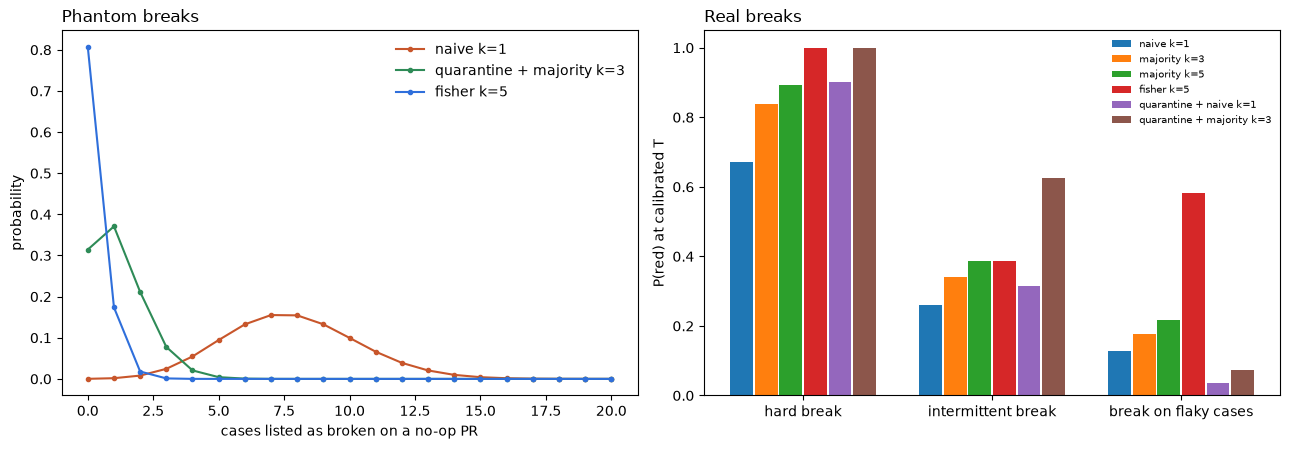

In [4]:
for sc in SCENARIOS[1:]:
    print(sc)
    for r in ev:
        x = r[sc]
        print(f"   {r['rule']:<27} P(red) {x['red_at_T']:.3f}   recall {x['recall']:.3f}   precision {x['precision']:.3f}"
              f"   calls {r['calls_per_pr']:,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name, col in (("naive k=1", "#c8562b"), ("quarantine + majority k=3", "#2e8b57"), ("fisher k=5", "#2f6fdb")):
    lab, kind, k, quar = next(x for x in RULES if x[0] == name)
    axes[0].plot(count_pmf(flag_prob(pi_a, pi_a, kind, k, quar))[:21], "o-", color=col, ms=3, label=name)
axes[0].set_xlabel("cases listed as broken on a no-op PR"); axes[0].set_ylabel("probability"); axes[0].legend(frameon=False)
axes[0].set_title("Phantom breaks", loc="left")
xs = np.arange(3)
for j, r in enumerate(ev):
    axes[1].bar(xs + (j - 2.5) * 0.13, [r[sc]["red_at_T"] for sc in SCENARIOS[1:]], 0.12, label=r["rule"])
axes[1].set_xticks(xs); axes[1].set_xticklabels(SCENARIOS[1:]); axes[1].set_ylabel("P(red) at calibrated T")
axes[1].legend(frameon=False, fontsize=7); axes[1].set_title("Real breaks", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()

Fisher's exact test on 5 runs each catches a hard break every time and 97% of the cases it lists are real,
at five times the model calls of one run. But it is the weakest rule on an *intermittent* break (a case
that now passes half the time): with 5 runs, 5-of-5 against 2-of-5 is not significant, so recall drops to
0.18. Majority-of-k has the opposite profile. No rule wins on all three kinds of break.

A side result pinned by a test: one-sided Fisher at k = 3 can never fire, because 3/3 vs 0/3 gives
p = 0.05 exactly. Choose k >= 4 before choosing Fisher.

## 4. Negative result - quarantine

In [5]:
q, m = next(r for r in ev if r["rule"] == "quarantine + majority k=3"), next(r for r in ev if r["rule"] == "majority k=3")
print(f"cases gated after quarantine: {q['gated_cases']:.1f} of {N}")
for sc in SCENARIOS[1:]:
    print(f"{sc:<22} majority k=3 {m[sc]['red_at_T']:.3f}  ->  with quarantine {q[sc]['red_at_T']:.3f}")

cases gated after quarantine: 271.7 of 300
hard break             majority k=3 0.837  ->  with quarantine 1.000
intermittent break     majority k=3 0.342  ->  with quarantine 0.627
break on flaky cases   majority k=3 0.178  ->  with quarantine 0.073


Quarantining cases whose baseline runs disagree is the standard fix for flaky tests, and here it does
what it promises: phantom breaks fall from 5.6 to 1.1, the threshold from 10 to 4, and power on stable
breaks rises to 1.00 and 0.63. The price is that a break on a flaky case is caught 7% of the time. The
gate is quiet because it has stopped looking at 28 of the 300 cases.

## Summary

| claim | what the numbers say |
|---|---|
| "zero regressions allowed" | a no-op PR is red 100% of the time on one run, 19% even with Fisher on 5 |
| "the diff report lists what broke" | on a real 6-case break, 43% of the naive list is real |
| "just re-run it more" | k = 5 majority: 55% precision at 5x the calls; Fisher 97%, but 0.18 recall on intermittent breaks |
| "quarantine the flaky cases" | quiet and powerful on stable cases, 0.07 on a break among the flaky ones |

## 5. Try your own

In [6]:
# baseline  = [[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 0]]   # cases x runs, 0/1
# candidate = [[0, 0, 0], [0, 1, 1], [1, 1, 1], [0, 0, 0]]
# res = audit(baseline, candidate)
# print("naive:", res["naive"], " majority:", res["majority"], " flaky:", res["flaky"],
#       f" no-op floor {res['noop_floor_naive']:.2f}")
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/prompt-regression-ci)

Streamlit version, where you paste your own baseline and candidate runs:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`golden-set-builder`](../golden-set-builder) asks whether the held-out set still
represents traffic; [`prompt-registry`](../prompt-registry) versions the prompt text;
[`prompt-linter`](../prompt-linter) reviews it statically.